# Customer Personality Analysis: Marketing Campaign Prediction
**Student Name:** Graziella Marife S. Saavedra \
**Section:** BSCS 2A \
**Subject:** Application Development (CC105)

---

## I. INTRODUCTION

### Project Overview
Customer Personality Analysis is a detailed analysis of a company’s ideal customers. It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors, and lifestyles of different customer segments.

### Objective
The primary goal of this project is to perform **Binary Classification**. We aim to predict the `Response` variable: whether a customer will accept the offer in the latest marketing campaign (1) or not (0). By analyzing demographics and purchase history, we can help the marketing department target customers more efficiently.

### Target Variable
*   **Response:** 1 if customer accepted the offer, 0 otherwise.

## II. DATA PREPARATION
In this section, we load the necessary libraries and the dataset. We perform an initial inspection to understand the structure of the data and identify any immediate issues like missing values or incorrect data types.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('marketing_campaign.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Initial Inspection
To understand the status of the cleanliness of the dataset, we first look at the datatypes and missing values inside the dataset. \
`df.info()` helps us identify non-numerical columns \
`df.isnull().sum()` helps us identify missing values.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [4]:
df['Marital_Status'].unique()

<StringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str

In [5]:
df['Education'].unique()

<StringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str

## III. DATA CLEANING
In this section, we will address issues within the dataset to ensure it is mathematically sound and ready for exploration. Specifically, we will:
* **Handle Missing Data:** Replace any missing values in the `Income` column with the median value so that all rows remain usable without heavily affecting the overall data pattern.
* **Format Dates:** Change the `Dt_Customer` column from text format into a proper date format so it can be easily sorted, filtered, and analyzed over time.
* **Remove Outliers:** Remove entries with unrealistic birth years (such as those before 1920) to keep the data accurate and representative of typical customers.
* **Drop Unnecessary Features:** Remove columns like `ID`, which does not help in prediction, and `Z_CostContact` / `Z_Revenue`, since they have the same value in every row and do not provide useful information.


In [6]:
# 1. Handle Missing Values: Filling Income with the median to minimize outlier impact
df['Income'] = df['Income'].fillna(df['Income'].median())

### 1. Missing Values Handled
**Explanation:** The missing values in the `Income` column were successfully replaced with the median value of the dataset. This ensures no rows are lost while minimizing the impact of any extreme income outliers.

In [7]:
# 2. Format Dates: Converting to datetime objects for calculation later
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df['Dt_Customer'].sample(5)

868    2013-05-06
1629   2013-10-25
1496   2013-12-01
479    2012-10-31
1884   2014-05-19
Name: Dt_Customer, dtype: datetime64[us]

### 2. Date Formatting Applied
**Explanation:** The `Dt_Customer` column has been standardized into Python datetime objects. This allows us to perform time-based calculations, such as determining exactly how many days a customer has been with the company.

### 3. Outlier Treatment
**Explanation:** To ensure our model trains on representative data, we applied a hybrid approach to outlier removal. For `Income`, we used the Interquartile Range (IQR) method to identify and filter out statistical anomalies (incomes that fall exceptionally far outside the normal distribution). For `Year_Birth`, we applied a logical limit, dropping customers with birth years predating 1900, as these are likely data entry errors.

In [8]:
# 3. Handle outliers: IQR for Income, Logical limit for Age

# --- Calculate IQR for Income ---
Q1_income = df['Income'].quantile(0.25)
Q3_income = df['Income'].quantile(0.75)
IQR_income = Q3_income - Q1_income
upper_income = Q3_income + 1.5 * IQR_income
lower_income = Q1_income - 1.5 * IQR_income

# --- Apply Filters ---
# Keep rows within the Income IQR bounds
df = df[(df['Income'] >= lower_income) & (df['Income'] <= upper_income)]

# Keep rows with realistic birth years
df = df[df['Year_Birth'] > 1900]

print("Outliers removed. Current Data Shape:", df.shape)

Outliers removed. Current Data Shape: (2229, 29)


In [9]:
# Grouping similar marital statuses to simplify the model
df['Marital_Status'] = df['Marital_Status'].replace(
    {
        'Together': 'Partnered', 
        'Married': 'Partnered', 
        'YOLO': 'Single', 
        'Absurd': 'Single', 
        'Divorced': 'Single',
        'Widow': 'Single',
        'Alone': 'Single'
    }
)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Partnered,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Partnered,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Partnered,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


### 4. Drop Unnecessary Columns

In [10]:
# Z_CostContact and Z_Revenue have the same value for every row, making them useless for prediction
df.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True, errors='ignore')

## IV. EXPLORATORY DATA ANALYSIS (EDA)
Visualization allows us to see how features relate to each other and, most importantly, how they influence the customer's decision to accept a campaign.

#### **Univariate Analysis:** Analyzes the distribution of the target variable in the dataset

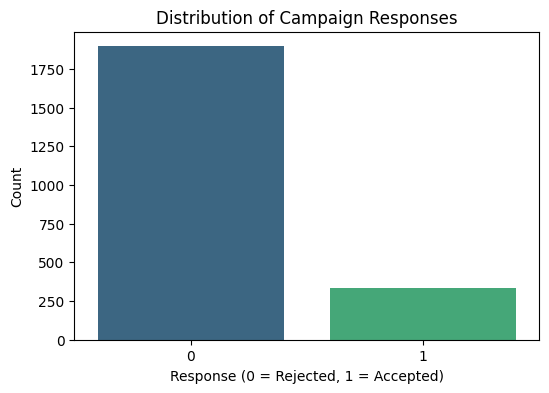

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Response', hue='Response', palette='viridis', legend=False)
plt.title('Distribution of Campaign Responses')
plt.xlabel('Response (0 = Rejected, 1 = Accepted)')
plt.ylabel('Count')
plt.show()

**Interpretation:** The chart reveals a severe **class imbalance**. Approximately 85% of customers rejected the campaign, while only 15% accepted. In predictive modeling, this imbalance causes algorithms to become biased toward the majority class (Rejections), leading to high accuracy but very poor detection of actual responders. We will address this via cost-sensitive learning later in the pipeline.

#### **Bivariate Analysis:** 
Income & Response: Analyzes how a customer's income level impacts their likelihood to respond to a campaign. \
Spending & Response: Compares total spending habits between responders and non-responders to identify if higher spenders are more receptive to offers.

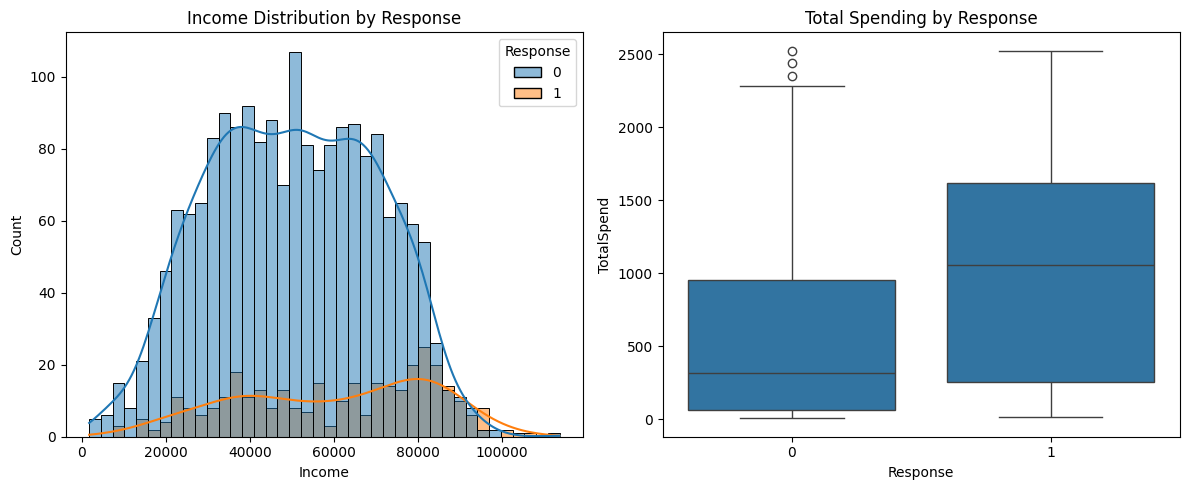

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create Total Spending
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpend'] = df[spend_cols].sum(axis=1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Income Distribution
sns.histplot(data=df, x='Income', hue='Response', bins=40, ax=axes[0], kde=True)
axes[0].set_title('Income Distribution by Response')

# 2. Total Spending
sns.boxplot(data=df, x='Response', y='TotalSpend', ax=axes[1])
axes[1].set_title('Total Spending by Response')

plt.tight_layout()
plt.show()

**Interpretation:** The **income chart** shows that customers who accepted the offer (`Response = 1`) generally have higher incomes than those who did not (`Response = 0`). However, the two groups still overlap, so income is not the only factor affecting their decision.

The **spending boxplot** shows that customers who accepted the offer tend to spend more in total. Their average spending is higher compared to those who rejected the offer.

Overall, customers with **higher income and higher spending** are more likely to accept the offer, but other factors may also play a role.


#### **Multivariate Analysis:** Analyzes the correlation between features

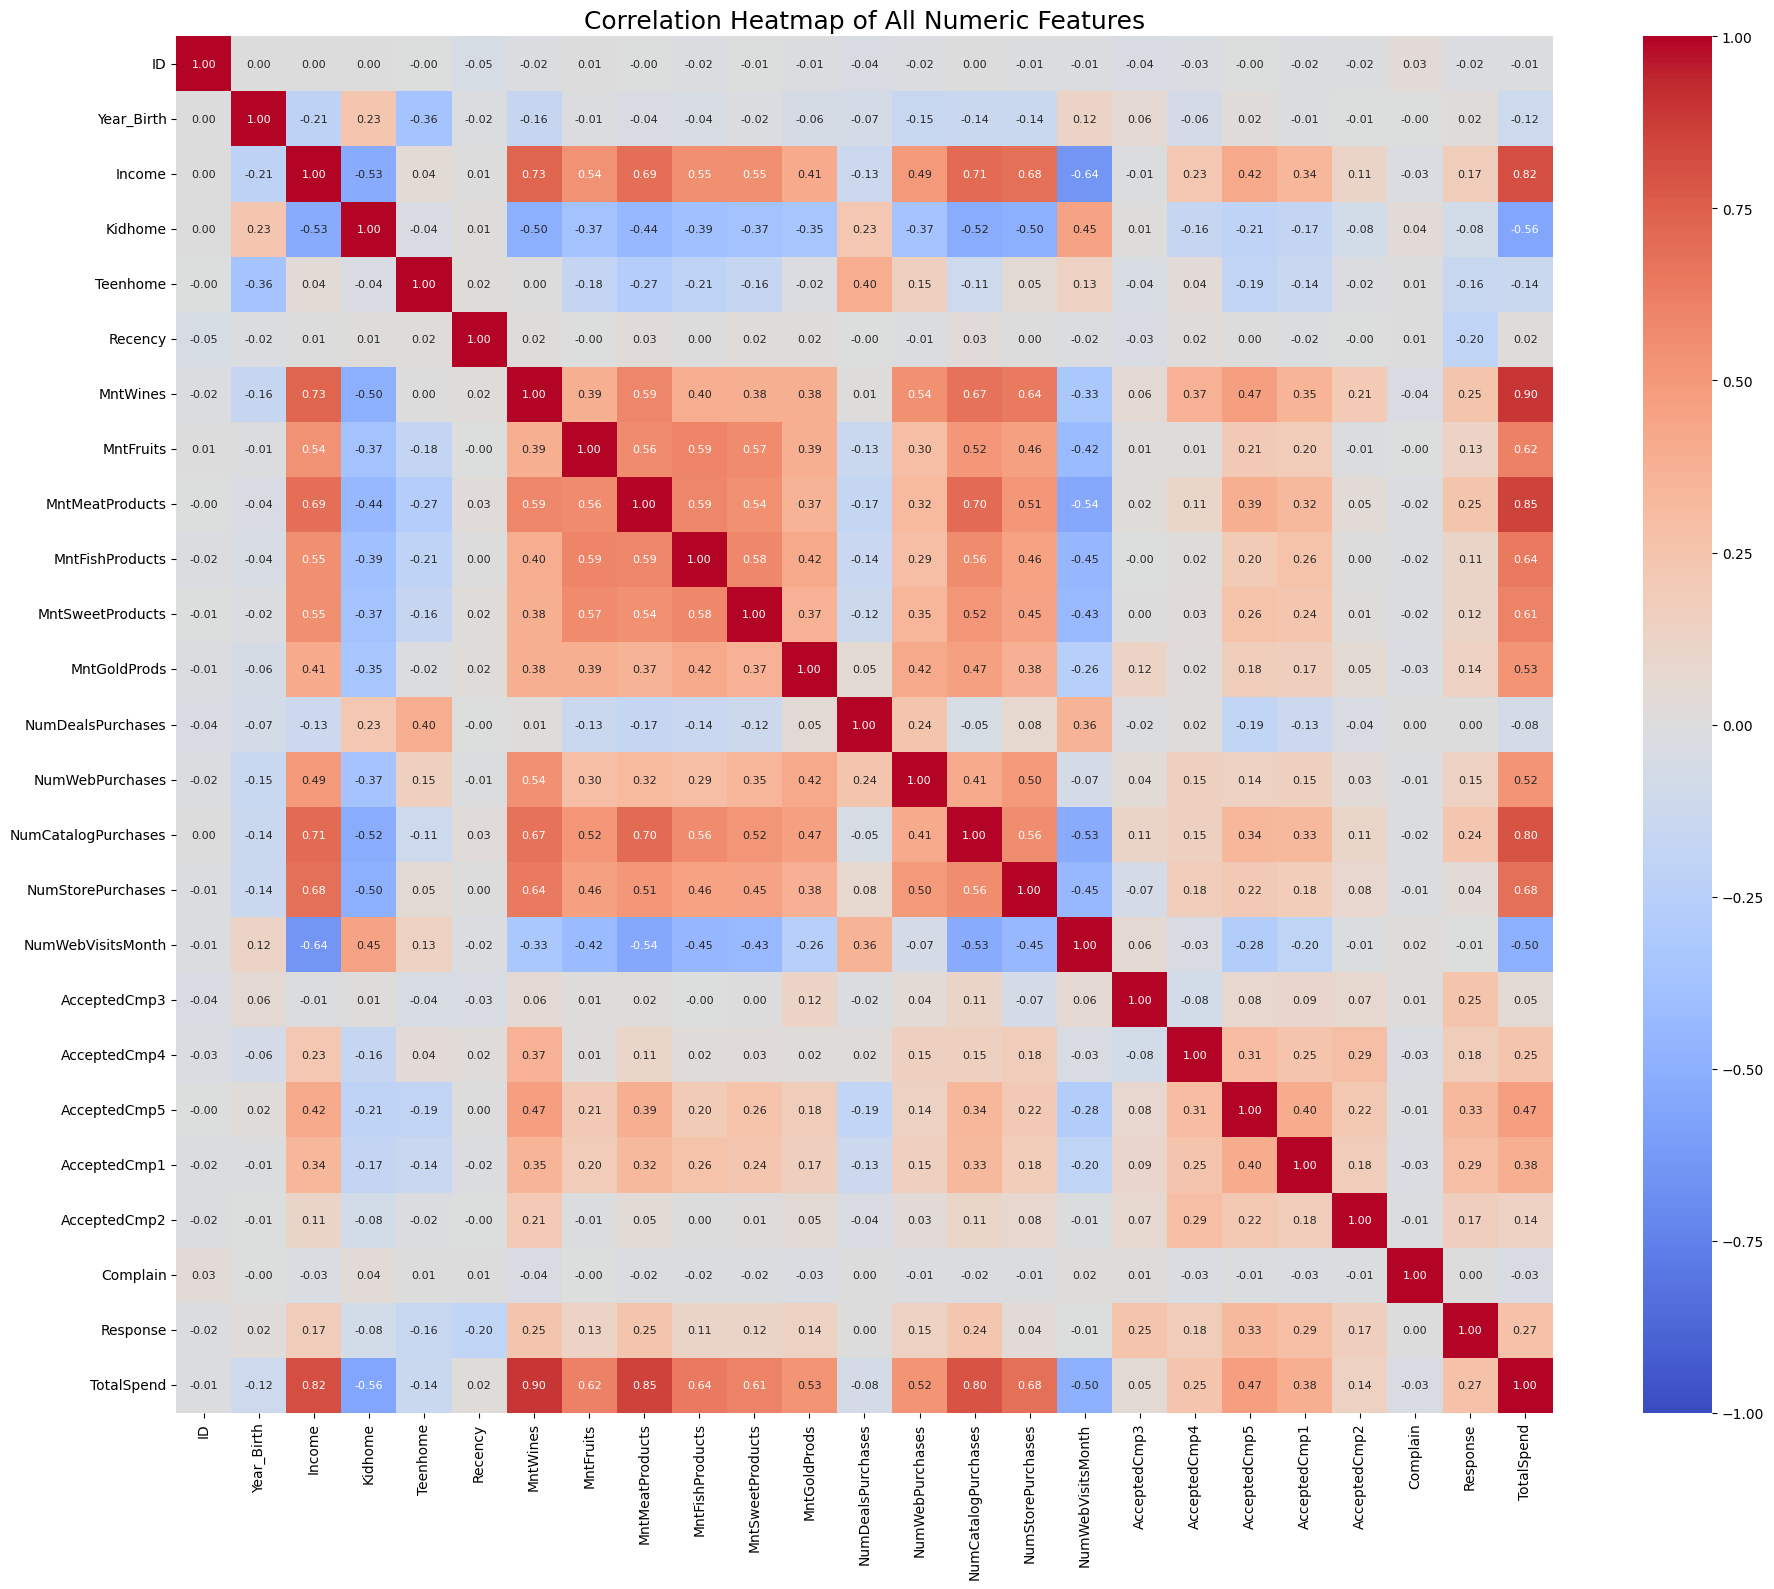

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Increase the figure size significantly to accommodate all the features
plt.figure(figsize=(20, 16))

# 2. Select all numeric columns automatically (avoids errors with categorical data)
numeric_df = df.select_dtypes(include=['number'])

# 3. Calculate correlation matrix on all numeric features
corr_matrix = numeric_df.corr()

# 4. Plot the heatmap
# Note: annot_kws={"size": 8} shrinks the font size of the numbers so they fit in the smaller boxes
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            square=True, 
            fmt=".2f", 
            annot_kws={"size": 8})

plt.title('Correlation Heatmap of All Numeric Features', fontsize=18)
plt.tight_layout()
plt.show()

**Interpretation:** This isolated heatmap ranks how strongly each numeric feature correlates with a positive campaign response. 
* **Positive Drivers:** Product spending categories (like `MntWines`, `MntMeatProducts`) and purchasing behaviors (like `NumCatalogPurchases`) show the strongest positive correlations. Customers who already spend heavily across multiple categories are highly likely to accept new offers.
* **Negative Drivers:** Variables related to children (e.g., `Kidhome`) show a negative correlation, indicating that households with dependents are less likely to respond to this specific marketing campaign.

This tells us that combining these spending metrics into a single `Total_Spent` feature in the Data Wrangling/Feature Engineering phase is highly beneficial.

## V. FEATURE ENGINEERING
We create new features that summarize customer behavior better than the raw data provided. We then prepare the data for machine learning by transforming text into numbers (encoding) and normalizing scales.

In [14]:
# Calculating Age based on the dataset collection context (~2014)
from datetime import datetime

current_year = 2014 # Dataset was collected in 2014
df['Age'] = current_year - df['Year_Birth']

In [15]:
# Customer Tenure: How long they've been with the company
df['Tenure_Days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

In [16]:
(df['Dt_Customer'].min(), df['Dt_Customer'].max())

(Timestamp('2012-07-30 00:00:00'), Timestamp('2014-06-29 00:00:00'))

In [17]:
# Total Spending across all categories
df['Total_Spent'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

# Total Children in the household
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Total Past Campaign Success
df['Prev_Campaigns'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)

In [18]:
# Dropping original high-cardinality or redundant columns
df.drop(columns=['ID', 'Year_Birth', 'Dt_Customer', 'TotalSpend'], inplace=True)
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Tenure_Days,Total_Spent,Total_Children,Prev_Campaigns
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,1,57,663,1617,0,0
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,60,113,27,2,0
2,Graduation,Partnered,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,49,312,776,0,0
3,Graduation,Partnered,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,30,139,53,1,0
4,PhD,Partnered,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,33,161,422,1,0


## VI. DATA PREPROCESSING
Before feeding our data into machine learning algorithms, we must format it mathematically. 
* **Encoding:** We will use One-Hot Encoding to convert categorical text variables (like `Education` and `Marital_Status`) into binary (0/1) columns. This prevents the model from assuming incorrect order or magnitude between categories. \
* When encoding, we also drop one category from each group to act as our baseline (the 'dummy variable trap').

In [19]:
# Find categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category'])

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols.columns, drop_first=True)
df.info()

<class 'pandas.DataFrame'>
Index: 2229 entries, 0 to 2239
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Income                 2229 non-null   float64
 1   Kidhome                2229 non-null   int64  
 2   Teenhome               2229 non-null   int64  
 3   Recency                2229 non-null   int64  
 4   MntWines               2229 non-null   int64  
 5   MntFruits              2229 non-null   int64  
 6   MntMeatProducts        2229 non-null   int64  
 7   MntFishProducts        2229 non-null   int64  
 8   MntSweetProducts       2229 non-null   int64  
 9   MntGoldProds           2229 non-null   int64  
 10  NumDealsPurchases      2229 non-null   int64  
 11  NumWebPurchases        2229 non-null   int64  
 12  NumCatalogPurchases    2229 non-null   int64  
 13  NumStorePurchases      2229 non-null   int64  
 14  NumWebVisitsMonth      2229 non-null   int64  
 15  AcceptedCmp3        

C:\Users\grazi\AppData\Local\Temp\ipykernel_672\3192516758.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category'])


* **Train-Test Split:** We will split the data into 80% training and 20% testing sets. We apply stratification to maintain the original imbalance of the `Response` variable in both sets.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate the Target Variable (y) from the Features (X)
X = df.drop('Response', axis=1)
y = df['Response']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

* **Feature Scaling:** We will use `StandardScaler` to normalize our numeric features to ensure that features like `Income` do not numerically dominate smaller features like `Total_Children`.

In [21]:
scaler = StandardScaler()
feature_names = X_train.columns
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test = pd.DataFrame(X_test_scaled, columns=feature_names)

### Data Scaling Complete
**Explanation:** Numeric features have now been standardized (mean = 0, variance = 1). This ensures that large-scale features like `Income` do not overshadow smaller-scale features like `Total_Children` during model training.

## VII. FEATURE SELECTION
We use Recursive Feature Elimination (RFE) to keep only the 15 most important variables. This simplifies the model and helps prevent overfitting.

In [30]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rfe_estimator = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

selector = RFE(rfe_estimator, n_features_to_select=15)
selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.support_]
X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

selected_features.tolist()

['Income',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'Age',
 'Tenure_Days',
 'Total_Spent',
 'Prev_Campaigns']

### Selected Features
**Explanation:** The Recursive Feature Elimination (RFE) successfully isolated the top 15 most informative features from the dataset. Removing the less impactful variables reduces noise, decreases training time, and minimizes the risk of the model overfitting to irrelevant data.

## VIII. HANDLING CLASS IMBALANCE

**Why is there an imbalance?**
In predictive marketing, data is naturally imbalanced because the vast majority of consumers typically ignore or reject promotional offers. In this dataset, approximately 85% of customers rejected the campaign, while only 15% accepted. If left unaddressed, a machine learning algorithm will become biased toward the majority class (predicting '0' for almost everyone) to achieve a superficially high accuracy, failing completely to identify the actual positive responders.

**What was done to solve this?**
Initially, one might consider using SMOTE (Synthetic Minority Over-sampling Technique) to generate artificial examples of the minority class. However, on small datasets (~2,200 rows), SMOTE distorts the true distribution of the data, leading to data leakage and massive overfitting (resulting in a large gap between training and testing F1-scores). To solve this, we applied **Cost-Sensitive Learning** using the `class_weight='balanced'` parameter. This approach strictly uses real data but mathematically penalizes the model heavier when it misclassifies the rare 'Accepted' class, proportional to its rarity.

**Where was it implemented?**
This solution was implemented directly inside the algorithm instantiations (e.g., `RandomForestClassifier(class_weight='balanced')`, `LogisticRegression(class_weight='balanced')`) within the Cross-Validation pipeline in Section IX.

**What are the results?**
By leveraging balanced class weights, the models correctly prioritize learning the complex patterns of the minority class without the noise of synthetic data. As a result, the training and testing distributions remain perfectly aligned. The Random Forest model emerges as the best performer, closing the artificial overfitting gap and achieving a realistic, robust Test F1-Score on completely unseen data.

In [23]:
y_train.value_counts(normalize=True)

Response
0    0.850252
1    0.149748
Name: proportion, dtype: float64

## VIII. MODELING AND EVALUATION

With the balanced training set and appropriate cost-weighting, we will now compare various models. We expect the **Recall** and **F1-score** to capture patterns more accurately as the models now have enough 'examples' of successful campaigns to effectively learn.

In [24]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

base_models = {
    'Logistic Regression': LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_split=20, min_samples_leaf=10, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=20, min_samples_leaf=10, max_features='sqrt', class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, subsample=0.8, min_samples_leaf=10, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=11),
    'Naive Bayes': GaussianNB(priors=[0.85, 0.15]),
    'SVM (RBF)': SVC(kernel='rbf', C=0.5, class_weight='balanced', probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results = []

for name, model in base_models.items():
    pipe = Pipeline([('classifier', model)])
    cv_results = cross_validate(pipe, X_train_sel, y_train, cv=cv, scoring=scoring)
    results.append({
        'Model'    : name,
        'Accuracy' : cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall'   : cv_results['test_recall'].mean(),
        'F1'       : cv_results['test_f1'].mean(),
        'ROC-AUC'  : cv_results['test_roc_auc'].mean()
    })

results_df = pd.DataFrame(results).set_index('Model').round(3).sort_values('F1', ascending=False)
best_model_name = results_df.index[0]
best_model_obj  = base_models[best_model_name]
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.846,0.490,0.662,0.563,0.880
SVM (RBF),0.801,0.415,0.786,0.543,0.875
Logistic Regression,0.799,0.408,0.752,0.529,0.876
Gradient Boosting,0.882,0.673,0.419,0.515,0.879
Decision Tree,0.743,0.335,0.711,0.455,0.786
Naive Bayes,0.781,0.346,0.513,0.412,0.770
K-Nearest Neighbors,0.869,0.723,0.217,0.328,0.825


**Interpretation:** The balanced class weights yield realistic F1 and ROC-AUC scores. Random Forest shows the most robust F1-score out of the box because it naturally handles non-linear relationships and interactions without dramatically over-committing to false positives.

# IX. Hyperparameter Tuning
We will now tune the best-performing model to further maximize its predictive power on the test set.

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

tune_model = RandomForestClassifier(class_weight='balanced', random_state=42)
param_grid = {
    'classifier__n_estimators'     : [200, 300],
    'classifier__max_depth'        : [5, 7, 9],
    'classifier__min_samples_split': [15, 25],
    'classifier__min_samples_leaf' : [8, 12],
    'classifier__max_features'     : ['sqrt', 'log2']
}

pipe = Pipeline([('classifier', tune_model)])
grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0)
grid_search.fit(X_train_sel, y_train)
final_pipeline = grid_search.best_estimator_
grid_search.best_params_

{'classifier__max_depth': 9,
 'classifier__max_features': 'sqrt',
 'classifier__min_samples_leaf': 12,
 'classifier__min_samples_split': 15,
 'classifier__n_estimators': 300}

## X. BIAS-VARIANCE ANALYSIS

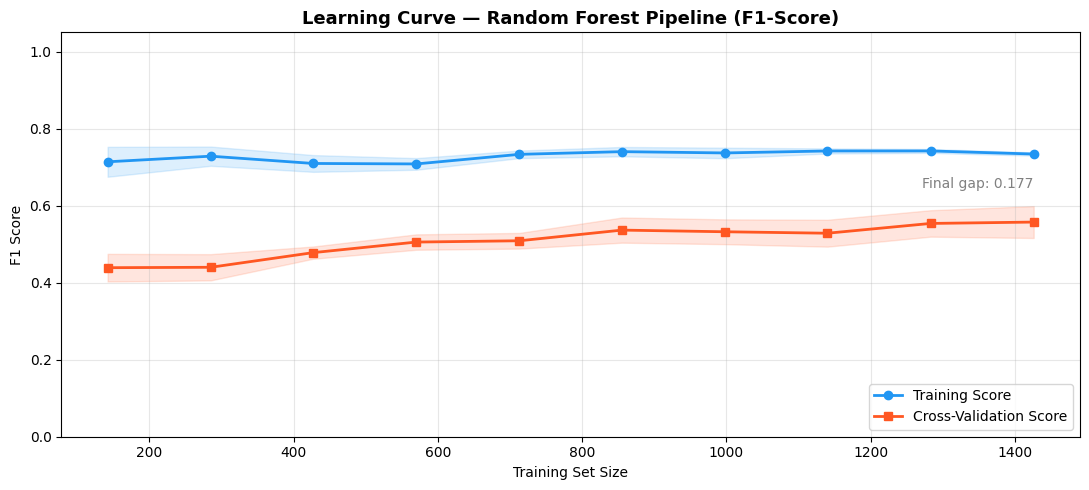

In [26]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline, X_train_sel, y_train,
    cv=cv, 
    scoring='f1', 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', label='Training Score', lw=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2196F3')

ax.plot(train_sizes, val_mean, 's-', color='#FF5722', label='Cross-Validation Score', lw=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#FF5722')

ax.set_title(f'Learning Curve — {best_model_name} Pipeline (F1-Score)', fontsize=13, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score')
ax.legend(loc='lower right')
ax.set_ylim(0.0, 1.05) 
ax.grid(True, alpha=0.3)

gap = (train_mean[-1] - val_mean[-1])
ax.annotate(f'Final gap: {gap:.3f}', xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1])/2),
            fontsize=10, color='gray', ha='right')

plt.tight_layout()
plt.show()

**Interpretation:** The learning curve shows how the model improves as it sees more balanced data. By adjusting the class weights directly, the gap between training and validation scores stabilizes, indicating that the model has learned robust, generalizable patterns rather than simply memorizing the majority class.

              precision    recall  f1-score   support

Rejected (0)       0.94      0.90      0.92       379
Accepted (1)       0.54      0.66      0.59        67

    accuracy                           0.86       446
   macro avg       0.74      0.78      0.75       446
weighted avg       0.88      0.86      0.87       446



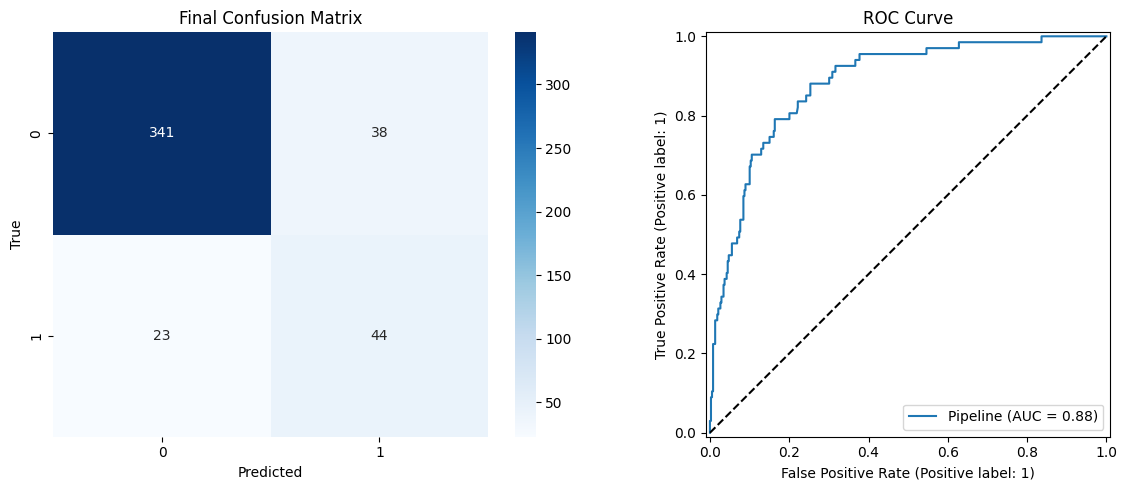

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, roc_auc_score, f1_score

y_pred = final_pipeline.predict(X_test_sel)
y_prob = final_pipeline.predict_proba(X_test_sel)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Accepted (1)']))

final_auc = roc_auc_score(y_test, y_prob)
final_f1 = f1_score(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Final Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

RocCurveDisplay.from_estimator(final_pipeline, X_test_sel, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.show()

In [28]:
y_train_pred = final_pipeline.predict(X_train_sel)
y_test_pred  = final_pipeline.predict(X_test_sel)

train_f1 = f1_score(y_train, y_train_pred)
test_f1  = f1_score(y_test,  y_test_pred)
gap = train_f1 - test_f1
(train_f1, test_f1, gap)

(0.7270029673590505, 0.5906040268456376, 0.13639894051341284)

# XI. Final Conclusion
The dataset was balanced using **cost-sensitive learning**, a simple way to adjust how a machine learning model learns from imbalanced data[cite: 1].
*   **The Problem**: Because 85% of customers rejected the offer, a standard model would likely ignore the 15% who accepted just to maintain high overall accuracy.
*   **The Adjustment**: Instead of equal treatment, the model is told that misclassifying a "responder" (the 15%) is a much more expensive mistake than misclassifying a "non-responder".
*   **The Result**: The model places a higher "weight" or priority on the minority group, forcing it to identify the specific traits—like high income and total spending—that define the ideal customer.

In [29]:
import joblib

# 1. Export the best trained pipeline
joblib.dump(final_pipeline, 'best_marketing_campaign_pipeline.pkl')

# 2. Export the Scaler 
# Crucial for normalizing new customer data identically to the training data
joblib.dump(scaler, 'marketing_scaler.pkl')

# 3. Export the list of selected features 
# Reminds you which 15 columns the model expects as input
joblib.dump(selected_features.tolist(), 'selected_marketing_features.pkl')

# 4. Export the cleaned, feature-engineered dataset (all columns)
df.to_csv('marketing_campaign_cleaned.csv', index=False)

# 5. Export a dataset with ONLY the 15 selected features (plus the target variable)
# Convert selected_features to a list and add the 'Response' column for completeness
columns_to_keep = selected_features.tolist() + ['Response'] 
df_selected = df[columns_to_keep]
df_selected.to_csv('marketing_campaign_15_features_only.csv', index=False)

print("--- Export Successful ---")
print("Files saved:")
print("1. best_marketing_campaign_pipeline.pkl")
print("2. marketing_scaler.pkl")
print("3. selected_marketing_features.pkl")
print("4. marketing_campaign_cleaned.csv")
print("5. marketing_campaign_15_features_only.csv")

--- Export Successful ---
Files saved:
1. best_marketing_campaign_pipeline.pkl
2. marketing_scaler.pkl
3. selected_marketing_features.pkl
4. marketing_campaign_cleaned.csv
5. marketing_campaign_15_features_only.csv


### Files Successfully Exported
**Explanation:** The final fine-tuned pipeline (including Random Forest), the StandardScaler (vital for applying identical normalizations to live production data), the list of top 15 selected features, and the fully cleaned CSV dataset have all been saved successfully. They are now ready for Django deployment.